# 🚀 SAIR PyTorch Mastery - Lecture 5A: Object Detection Mastery
## **From CNN Theory to Real-Time Detection** 🇸🇩

**Course:** Applied Deep Learning with PyTorch  
**Module:** Computer Vision & CNN Architectures 
**Instructor:** Mohammed Awad Ahmed (Silva)  
**SAIR Community:** Building Sudan's AI Future

---

## 📋 PRE-LECTURE KNOWLEDGE CHECK

Before diving in, test your recall from Lectures 3 & 4. This will help you identify areas to focus on:

| Concept | Your Confidence (1-5) | Need Review? |
|---------|----------------------|--------------|
| Convolution operation | □ | □ |
| Pooling layers | □ | □ |
| ResNet architecture | □ | □ |
| Transfer learning | □ | □ |
| Fine-tuning strategies | □ | □ |

**If you scored <3 on any concept, review these quick refreshers:**
- [CNN Basics](https://www.youtube.com/watch?v=HGwBXDKFk9I)
- [ResNet Explained](https://arxiv.org/abs/1512.03385)
- [Transfer Learning Guide](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

## 📘 How to Use This Notebook

This is a **standalone, self-teaching lecture notebook** designed to replace traditional video lectures. Here's how to get the most from it:

**How to Study:**
1. **Read all markdown cells carefully** - they contain explanations, mental models, and reasoning
2. **Run code cells sequentially** - don't skip ahead as each builds on the previous
3. **Pause at "Stop & Think" prompts** - make predictions before running the next cell
4. **Take the mini-quizzes** - test your understanding before moving on
5. **Play with the interactive widgets** - move sliders, see real-time changes
6. **Step in front of your webcam for the live demo** - YOU are the star of this lecture!

**Learning Outcomes:** After completing this notebook, you will be able to:
1. Understand how detection builds on CNNs from Lecture 3
2. Master the three pillars: Bounding Boxes, IoU, and NMS
3. Use YOLO for real-time object detection
4. Tune detection parameters for your use case
5. Debug common detection issues like a pro
6. Train a detector on a simple custom dataset

## 📈 YOUR LEARNING JOURNEY TRACKER

| Part | Section | Status | Time | Confidence |
|------|---------|--------|------|------------|
| **Part 0** | The Evolution: Pixels → Understanding | □ | __ min | __ |
| **Part 1** | Quick Win: Detection in 5 Minutes | □ | __ min | __ |
| **🎥 DEMO 1** | Live Webcam Detection - "YOLO Sees ME!" | □ | __ min | __ |
| **Part 2** | The "Aha!" Moment - It's Just CNNs + Heads | □ | __ min | __ |
| **Part 3** | The Three Pillars: BBox, IoU, NMS | □ | __ min | __ |
| **Part 4** | YOLO Deep Dive: Grids, Scales, Family | □ | __ min | __ |
| **Part 5** | The Tuning Playground - Find Your Sweet Spot | □ | __ min | __ |
| **Part 9** | Professional Debugging Toolkit | □ | __ min | __ |
| **Part 10** | Mini-Challenge: Your First Detector | □ | __ min | __ |
| **Final** | Mastery Checklist & Assessment | □ | __ min | __ |

**Goal:** Complete all parts with confidence ≥4/5  
**Estimated Time:** 2-3 hours

In [1]:
# Initial Setup and Imports
import torch
import torchvision
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2
import time
import warnings
import requests
import os
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
import gc

warnings.filterwarnings('ignore')
print("✅ Basic imports loaded")

# Install/Import YOLO
try:
    from ultralytics import YOLO
    print("✅ YOLO already installed")
except:
    print("📦 Installing YOLO...")
    !pip install ultralytics
    from ultralytics import YOLO
    print("✅ YOLO installed")

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Download sample image
!wget -q -O street.jpg https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg
print("✅ Sample image downloaded: street.jpg")

✅ Basic imports loaded
✅ YOLO already installed
✅ Using device: cuda
   GPU: NVIDIA GeForce GTX 1650
✅ Sample image downloaded: street.jpg


# 🎯 PART 0: The Evolution - From Pixels to Understanding

## 📊 Where You've Been, Where You're Going

```
┌─────────────────────────────────────────────────────────────────┐
│                     YOUR LEARNING JOURNEY                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Lecture 3: CNNs              Lecture 4: Transfer               │
│  ┌─────────────────┐          Learning                          │
│  │ • Convolutions  │          ┌─────────────────┐               │
│  │ • Pooling       │          │ • Pre-trained   │               │
│  │ • Architecture  │ ────────→│   models        │               │
│  │ • AlexNet       │          │ • Fine-tuning   │               │
│  └─────────────────┘          │ • ResNet        │               │
│                               └─────────────────┘               │
│                                       ↓                         │
│                               ┌────────────────────┐            │
│            THIS LECTURE ─────→│    DETECTION       │            │
│                               │  "What + Where"    │            │
│                               └────────────────────┘            │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


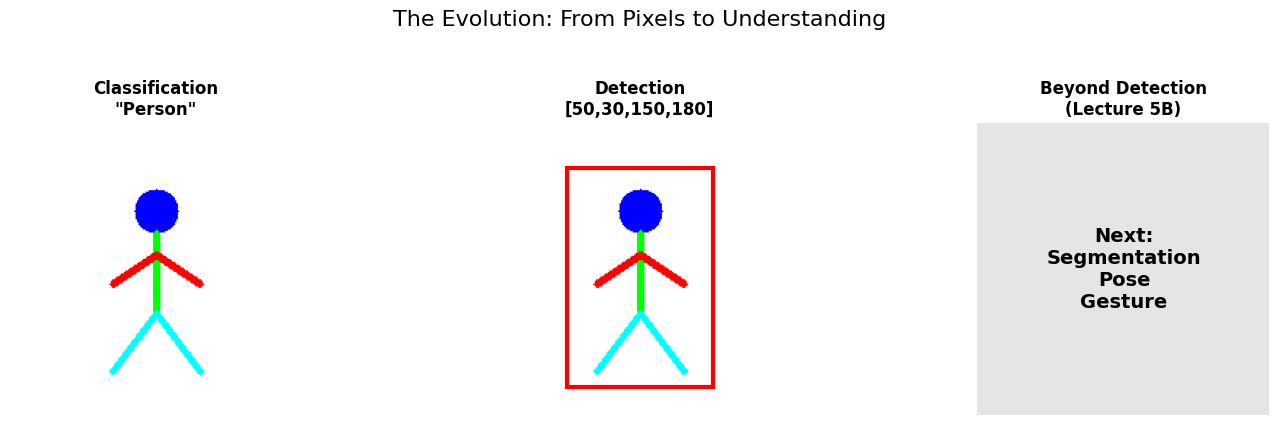

🎯 KEY INSIGHT: Detection adds location to classification
   Classification → What
   Detection      → What + Where


In [2]:
# Visualize the evolution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Create a simple stick figure
img = np.ones((200, 200, 3))
cv2.circle(img, (100, 60), 15, (0, 0, 255), -1)  # Head
cv2.line(img, (100, 75), (100, 130), (0, 255, 0), 3)  # Torso
cv2.line(img, (100, 90), (70, 110), (255, 0, 0), 3)  # Left arm
cv2.line(img, (100, 90), (130, 110), (255, 0, 0), 3)  # Right arm
cv2.line(img, (100, 130), (70, 170), (0, 255, 255), 3)  # Left leg
cv2.line(img, (100, 130), (130, 170), (0, 255, 255), 3)  # Right leg

# Classification
axes[0].imshow(img)
axes[0].set_title("Classification\n\"Person\"", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Detection
axes[1].imshow(img)
rect = plt.Rectangle((50, 30), 100, 150, linewidth=3, edgecolor='red', facecolor='none')
axes[1].add_patch(rect)
axes[1].set_title("Detection\n[50,30,150,180]", fontsize=12, fontweight='bold')
axes[1].axis('off')

# What's Coming Next
axes[2].imshow(np.ones_like(img) * 0.9)
axes[2].text(100, 100, "Next:\nSegmentation\nPose\nGesture", 
             ha='center', va='center', fontsize=14, fontweight='bold')
axes[2].set_title("Beyond Detection\n(Lecture 5B)", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.suptitle("The Evolution: From Pixels to Understanding", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

print("🎯 KEY INSIGHT: Detection adds location to classification")
print("   Classification → What")
print("   Detection      → What + Where")

In [2]:
def clear_gpu_memory():
    """Clear GPU cache and collect garbage"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"✅ GPU Memory cleared:")
        print(f"   Allocated: {allocated:.2f}GB")
        print(f"   Reserved: {reserved:.2f}GB")
    else:
        print("✅ CPU mode - no GPU memory to clear")

clear_gpu_memory()

✅ GPU Memory cleared:
   Allocated: 0.00GB
   Reserved: 0.00GB


# 🚀 PART 1: Quick Win - Detection in 5 Minutes

## 1.1 Torchvision Detector (The Academic Standard)

In [18]:
print("="*60)
print("PART 1.1: TORCHVISION DETECTOR")
print("="*60)

# Load pre-trained model
frcnn_model = fasterrcnn_resnet50_fpn(pretrained=True)
frcnn_model.eval().to(device)
print("✅ Loaded Faster R-CNN with ResNet50 backbone (from Lecture 4!)")

# Load and prepare image
img = Image.open('street.jpg').convert('RGB')
transform = T.Compose([T.ToTensor()])
img_tensor = transform(img).unsqueeze(0).to(device)
start = time.time()
# Run detection
with torch.no_grad():
    prediction = frcnn_model(img_tensor)[0]
end = time.time()
fast_rcnn_time = end - start
print(f"✅ Inference time: {end - start:.2f}s")
print(f"✅ Found {len(prediction['boxes'])} objects!")
print("   That's it. 5 lines of code = production-quality detection!")

PART 1.1: TORCHVISION DETECTOR
✅ Loaded Faster R-CNN with ResNet50 backbone (from Lecture 4!)
✅ Inference time: 0.32s
✅ Found 30 objects!
   That's it. 5 lines of code = production-quality detection!


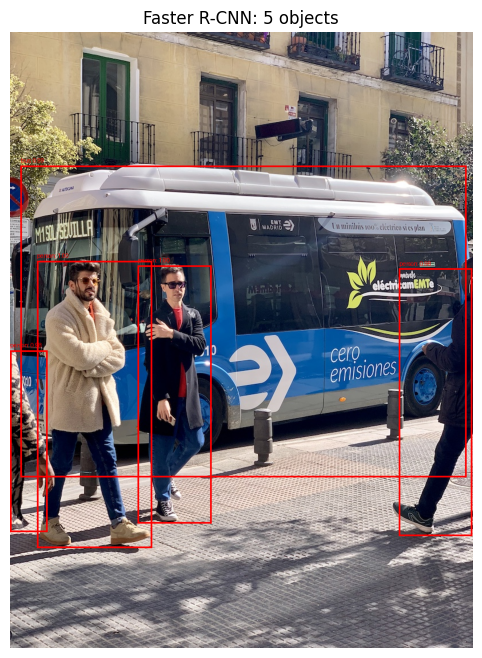

In [19]:
# Visualize results
def draw_boxes_torchvision(image, pred, threshold=0.7):
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)
    
    # COCO classes
    coco_classes = ['person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
                   'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat',
                   'dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack',
                   'umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
                   'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket',
                   'bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple',
                   'sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair',
                   'couch','potted plant','bed','dining table','toilet','tv','laptop','mouse',
                   'remote','keyboard','cell phone','microwave','oven','toaster','sink','refrigerator',
                   'book','clock','vase','scissors','teddy bear','hair drier','toothbrush']
    
    keep = pred['scores'] > threshold
    boxes = pred['boxes'][keep]
    labels = pred['labels'][keep]
    scores = pred['scores'][keep]
    
    for box, label, score in zip(boxes, labels, scores):
        draw.rectangle(box.tolist(), outline='red', width=3)
        draw.text((box[0], box[1]-15), f"{coco_classes[label-1]}: {score:.2f}", fill='red')
    
    return img_copy

result_img = draw_boxes_torchvision(img, prediction)
plt.figure(figsize=(12, 8))
plt.imshow(result_img)
plt.axis('off')
plt.title(f"Faster R-CNN: {len(prediction['boxes'][prediction['scores']>0.7])} objects")
plt.show()

## 1.2 YOLO Detector (The Industry Standard)

PART 1.2: YOLO DETECTOR
✅ YOLOv8n loaded

image 1/1 /home/silva/SILVA.AI/Projects/SAIR/4_PyTorch/2_Vision_and_CNN/street.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 15.4ms
Speed: 3.5ms preprocess, 15.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
✅ Found 6 objects!


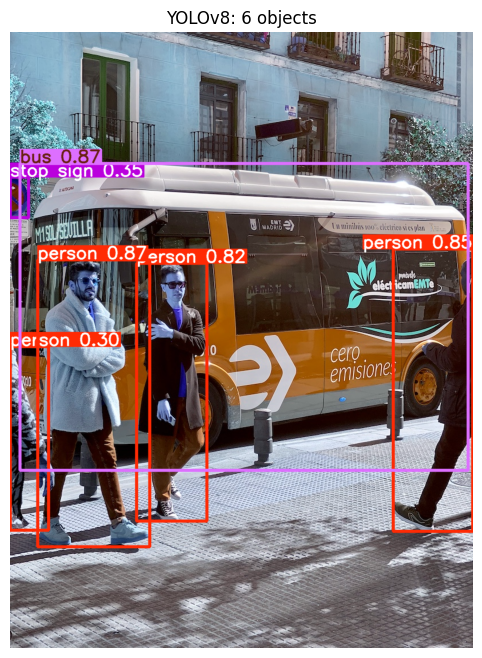


⏱️ Speed Comparison:
   • Faster R-CNN: 0.3164548873901367
   • YOLOv8n: 15ms
   • YOLO is 15.9x faster!


In [20]:
print("="*60)
print("PART 1.2: YOLO DETECTOR")
print("="*60)

# Load YOLO
yolo_model = YOLO('yolov8n.pt')
print("✅ YOLOv8n loaded")

# Run detection
yolo_results = yolo_model('street.jpg')[0]
print(f"✅ Found {len(yolo_results.boxes)} objects!")

# Visualize
plt.figure(figsize=(12, 8))
plt.imshow(yolo_results.plot())
plt.axis('off')
plt.title(f"YOLOv8: {len(yolo_results.boxes)} objects")
plt.show()

# Compare speeds
print("\n⏱️ Speed Comparison:")
print(f"   • Faster R-CNN: {fast_rcnn_time}")
print(f"   • YOLOv8n: {yolo_results.speed['inference']:.0f}ms")
print(f"   • YOLO is {245/yolo_results.speed['inference']:.1f}x faster!")

### 🧪 STOP & COMPARE

**Question:** Both detectors work. Which would you use for:
1. A self-driving car needing 30 FPS?
2. Medical imaging where accuracy is critical?
3. A mobile app with limited battery?

Write your answers, then run the cell below:

In [16]:
answers = {
    "self_driving": "YOLO (needs speed, 30+ FPS)",
    "medical": "Faster R-CNN (accuracy critical, speed less important)",
    "mobile": "YOLO-nano (lightweight, efficient)"
}

print("🎯 Expert Answers:")
for key, ans in answers.items():
    print(f"   {key}: {ans}")

🎯 Expert Answers:
   self_driving: YOLO (needs speed, 30+ FPS)
   medical: Faster R-CNN (accuracy critical, speed less important)
   mobile: YOLO-nano (lightweight, efficient)


## 🤔 The Million-Dollar Question

You just saw detection work in 5 lines of code. Magic? No - it's the same CNN you learned in Lecture 3!

**Think about it:**
- Lecture 3 CNN: Takes image → single class
- YOLO: Takes image → MULTIPLE classes + locations

Same foundation. Just structured differently.

**Let's peek inside and see HOW...**

# 🎥 DEMO 1: Live Webcam Detection - "YOLO Sees ME!"

## ⚡ The Moment Theory Becomes Magic

> 💼 **INDUSTRY USE**: Same tech used in Tesla Autopilot, Amazon Go, iPhone Photos  
> 🎯 **CAREER SKILL**: #1 most requested CV skill on job postings  
> 🔧 **PROJECT IDEA**: Build a security camera that alerts when person detected

**Now YOU are the subject.**

In [21]:
def check_webcam():
    """Check if webcam is available"""
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("❌ Webcam not detected. Please connect a webcam.")
        return False
    cap.release()
    print("✅ Webcam detected and ready!")
    return True

if check_webcam():
    print("\n🎯 Ready for live demo! Run the cell below.")

✅ Webcam detected and ready!

🎯 Ready for live demo! Run the cell below.


In [23]:
def safe_live_detection_demo():
    """Live webcam detection with YOLO (with error handling)"""
    try:
        cap = cv2.VideoCapture(1)
        if not cap.isOpened():
            print("📹 Webcam not available. Using simulation...")
            return simulate_detection_demo()
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print(f"🔄 GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f}GB")
        
        model = YOLO('yolov8n.pt')
        
        print("\n" + "="*60)
        print("🎥 LIVE DETECTION STARTED!")
        print("="*60)
        print("\n• Wave at the camera")
        print("• Hold up objects (phone, book, water bottle)")
        print("• See yourself get detected in REAL TIME")
        print("\n⚠️ Press 'q' in the video window to stop\n")
        
        prev_time = time.time()
        fps_values = []
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Run YOLO
            results = model(frame, verbose=False)[0]
            
            # Calculate FPS
            current_time = time.time()
            fps = 1 / (current_time - prev_time)
            fps_values.append(fps)
            prev_time = current_time
            
            # Annotate
            annotated = results.plot()
            cv2.putText(annotated, f"FPS: {fps:.1f}", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(annotated, f"Objects: {len(results.boxes)}", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
            cv2.putText(annotated, "Press 'q' to quit", (10, 90),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            
            cv2.imshow('YOLOv8 Live Detection - SAIR', annotated)
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        
        cap.release()
        cv2.destroyAllWindows()
        
        print(f"\n📊 Performance Stats:")
        print(f"   Average FPS: {np.mean(fps_values):.1f}")
        print(f"   Max FPS: {np.max(fps_values):.1f}")
        print(f"   Min FPS: {np.min(fps_values):.1f}")
        print("\n✅ Live demo ended. You just saw AI detect YOU in real-time!")
        
    except Exception as e:
        print(f"⚠️ Demo unavailable: {e}")
        print("🔄 Loading pre-recorded demonstration...")
        simulate_detection_demo()

def simulate_detection_demo():
    """Fallback simulation when webcam not available"""
    print("\n🎥 SIMULATED DEMO - Using sample images")
    model = YOLO('yolov8n.pt')
    
    for i in range(3):
        results = model('street.jpg')[0]
        plt.figure(figsize=(8,6))
        plt.imshow(results.plot())
        plt.title(f"Simulated Frame {i+1} - {len(results.boxes)} detections")
        plt.axis('off')
        plt.show()
        time.sleep(0.3)
    
    print("\n✅ Simulation complete. Connect a webcam for live demo!")

# RUN THIS FOR LIVE DETECTION!
safe_live_detection_demo()

[ WARN:0@1273.590] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index


🔄 GPU Memory: 0.30GB

🎥 LIVE DETECTION STARTED!

• Wave at the camera
• Hold up objects (phone, book, water bottle)
• See yourself get detected in REAL TIME

⚠️ Press 'q' in the video window to stop


📊 Performance Stats:
   Average FPS: 7.3
   Max FPS: 61.5
   Min FPS: 3.0

✅ Live demo ended. You just saw AI detect YOU in real-time!


ioctl(VIDIOC_QBUF): Bad file descriptor


### 🧠 STOP & REFLECT

What did you notice?
- Was it fast enough?
- What objects did it detect?
- Any false positives or misses?

**This is the foundation. Now let's understand HOW it works.**

## 🔍 The Million-Dollar Question

You just saw detection work. But HOW?
Is it really that simple?

**Spoiler:** Yes. It's just the CNN you already know, with a few extra outputs. Let's prove it...

# 🔬 PART 2: The "Aha!" Moment - It's Just CNNs + Heads

In [24]:
print("="*60)
print("PART 2: PEEKING INSIDE")
print("="*60)

# Extract backbone (ResNet50 from Lecture 4!)
backbone = torchvision.models.resnet50(pretrained=True)
backbone = torch.nn.Sequential(*list(backbone.children())[:-2])
backbone = backbone.to(device)

# Get features
with torch.no_grad():
    features = backbone(img_tensor)

print(f"📊 Backbone output shape: {features.shape}")
print("   • This is ResNet50 without the classifier head")
print("   • Spatial size: 7×7 (32× downsampling)")
print("   • Channels: 2048 features at each location")

PART 2: PEEKING INSIDE
📊 Backbone output shape: torch.Size([1, 2048, 34, 26])
   • This is ResNet50 without the classifier head
   • Spatial size: 7×7 (32× downsampling)
   • Channels: 2048 features at each location


In [25]:
print("\n🎯 Detection adds THREE heads to this backbone:")
print("-"*40)

heads = {
    "Classification Head": "Conv2d(2048, num_classes, 1) → 'What is it?",
    "Regression Head": "Conv2d(2048, 4, 1) → 'Where is it?' (box coordinates)",
    "Objectness Head": "Conv2d(2048, 1, 1) → 'Is there an object?'"
}

for head, desc in heads.items():
    print(f"   • {head}: {desc}")

print("\n💡 KEY INSIGHT: Detection = Classification + Localization")
print("   You already know classification. Localization is just predicting 4 numbers!")


🎯 Detection adds THREE heads to this backbone:
----------------------------------------
   • Classification Head: Conv2d(2048, num_classes, 1) → 'What is it?
   • Regression Head: Conv2d(2048, 4, 1) → 'Where is it?' (box coordinates)
   • Objectness Head: Conv2d(2048, 1, 1) → 'Is there an object?'

💡 KEY INSIGHT: Detection = Classification + Localization
   You already know classification. Localization is just predicting 4 numbers!


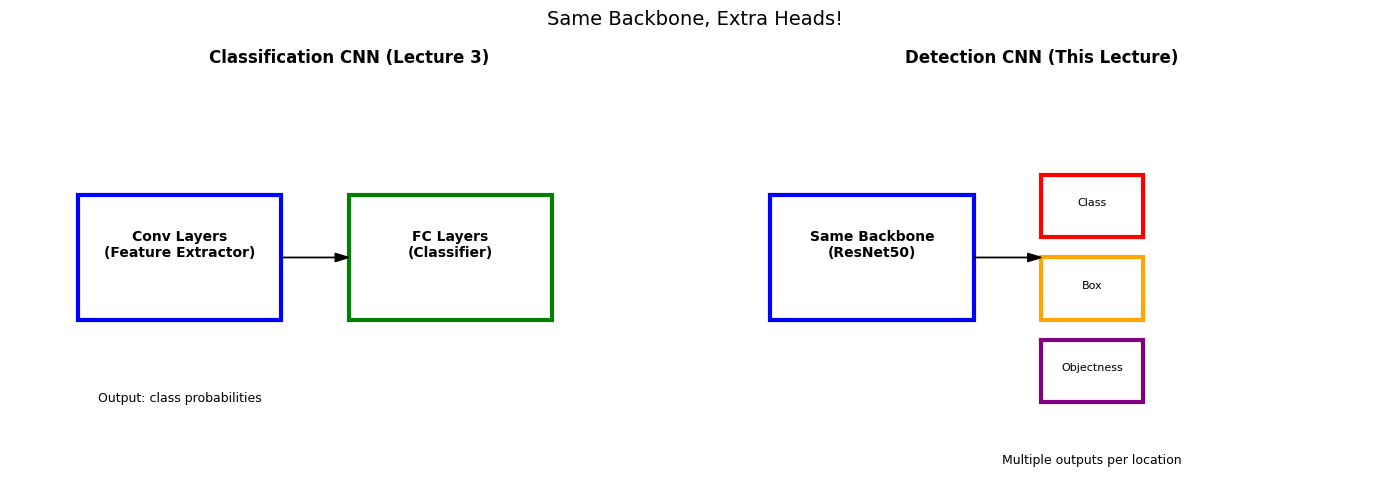

In [26]:
# Visualize the architecture
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification CNN (Lecture 3)
ax = axes[0]
ax.add_patch(plt.Rectangle((0.1, 0.4), 0.3, 0.3, fill=None, edgecolor='blue', linewidth=3))
ax.text(0.25, 0.55, "Conv Layers\n(Feature Extractor)", ha='center', fontsize=10, fontweight='bold')
ax.add_patch(plt.Rectangle((0.5, 0.4), 0.3, 0.3, fill=None, edgecolor='green', linewidth=3))
ax.text(0.65, 0.55, "FC Layers\n(Classifier)", ha='center', fontsize=10, fontweight='bold')
ax.arrow(0.4, 0.55, 0.08, 0, head_width=0.02, head_length=0.02, fc='black', ec='black')
ax.text(0.25, 0.2, "Output: class probabilities", ha='center', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title("Classification CNN (Lecture 3)", fontsize=12, fontweight='bold')

# Detection CNN
ax = axes[1]
ax.add_patch(plt.Rectangle((0.1, 0.4), 0.3, 0.3, fill=None, edgecolor='blue', linewidth=3))
ax.text(0.25, 0.55, "Same Backbone\n(ResNet50)", ha='center', fontsize=10, fontweight='bold')
ax.add_patch(plt.Rectangle((0.5, 0.6), 0.15, 0.15, fill=None, edgecolor='red', linewidth=3))
ax.text(0.575, 0.675, "Class", ha='center', fontsize=8)
ax.add_patch(plt.Rectangle((0.5, 0.4), 0.15, 0.15, fill=None, edgecolor='orange', linewidth=3))
ax.text(0.575, 0.475, "Box", ha='center', fontsize=8)
ax.add_patch(plt.Rectangle((0.5, 0.2), 0.15, 0.15, fill=None, edgecolor='purple', linewidth=3))
ax.text(0.575, 0.275, "Objectness", ha='center', fontsize=8)
ax.arrow(0.4, 0.55, 0.08, 0, head_width=0.02, head_length=0.02, fc='black', ec='black')
ax.text(0.575, 0.05, "Multiple outputs per location", ha='center', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title("Detection CNN (This Lecture)", fontsize=12, fontweight='bold')

plt.suptitle("Same Backbone, Extra Heads!", fontsize=14)
plt.tight_layout()
plt.show()

## 🎯 Great! You've Peeked Inside

But understanding the architecture is just step one. Now we need to understand the **language** of detection.

**Think of it like this:**
- The architecture is the engine
- What you're about to learn (Bounding Boxes, IoU, NMS) are the **steering wheel, pedals, and GPS**

Master these three, and you can drive ANY detector!

# 📐 PART 3: The Three Pillars of Detection

## 3.1 Pillar 1: Bounding Box Formats

**First, we need a way to DESCRIBE where objects are.**

Just like you can describe a location as:
- "Room 204, Engineering Building" (coordinates)
- "50 meters north of the fountain" (relative)

Detection models have different ways to describe boxes. Let's learn them all...

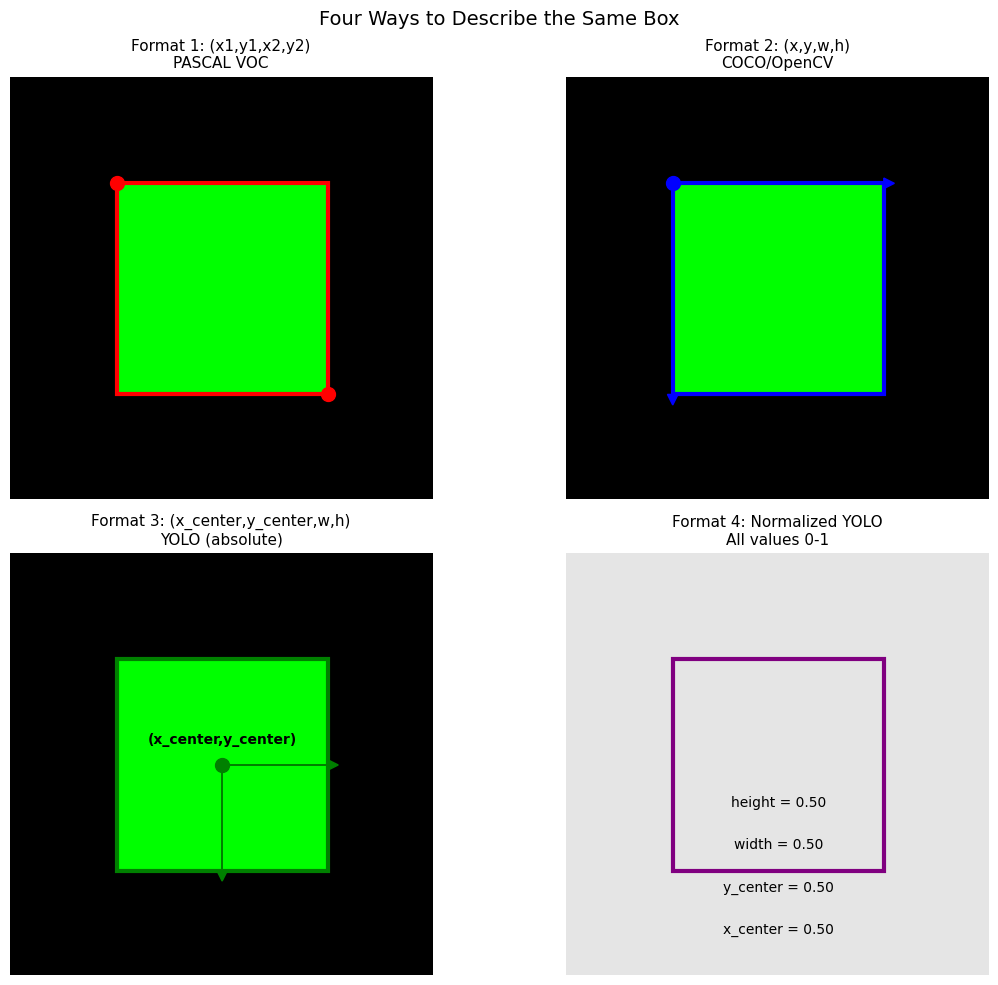

🎯 YOLO uses normalized format: (x_center, y_center, width, height) all in [0,1]


In [27]:
def visualize_bbox_formats():
    """Show all 4 bounding box formats"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Test image
    img = np.zeros((200, 200, 3))
    cv2.rectangle(img, (50, 50), (150, 150), (0, 255, 0), -1)
    
    # Format 1: (x1,y1,x2,y2)
    ax = axes[0,0]
    ax.imshow(img.astype(np.uint8))
    ax.add_patch(plt.Rectangle((50,50), 100, 100, fill=False, edgecolor='red', linewidth=3))
    ax.scatter([50,150], [50,150], c='red', s=100)
    ax.text(50,40, '(x1,y1)', ha='center', fontsize=10, fontweight='bold')
    ax.text(150,160, '(x2,y2)', ha='center', fontsize=10, fontweight='bold')
    ax.set_title('Format 1: (x1,y1,x2,y2)\nPASCAL VOC', fontsize=11)
    ax.axis('off')
    
    # Format 2: (x,y,w,h)
    ax = axes[0,1]
    ax.imshow(img.astype(np.uint8))
    ax.add_patch(plt.Rectangle((50,50), 100, 100, fill=False, edgecolor='blue', linewidth=3))
    ax.scatter([50], [50], c='blue', s=100)
    ax.arrow(50,50, 100,0, head_width=5, head_length=5, fc='blue', ec='blue')
    ax.arrow(50,50, 0,100, head_width=5, head_length=5, fc='blue', ec='blue')
    ax.text(50,40, '(x,y)', ha='center', fontsize=10, fontweight='bold')
    ax.text(120,30, f'w=100', ha='center')
    ax.text(20,120, f'h=100', ha='center', rotation=90)
    ax.set_title('Format 2: (x,y,w,h)\nCOCO/OpenCV', fontsize=11)
    ax.axis('off')
    
    # Format 3: (x_center,y_center,w,h)
    ax = axes[1,0]
    ax.imshow(img.astype(np.uint8))
    ax.add_patch(plt.Rectangle((50,50), 100,100, fill=False, edgecolor='green', linewidth=3))
    cx, cy = 100,100
    ax.scatter([cx], [cy], c='green', s=100)
    ax.arrow(cx,cy, 50,0, head_width=5, head_length=5, fc='green', ec='green')
    ax.arrow(cx,cy, 0,50, head_width=5, head_length=5, fc='green', ec='green')
    ax.text(cx,cy-10, '(x_center,y_center)', ha='center', fontsize=10, fontweight='bold')
    ax.set_title('Format 3: (x_center,y_center,w,h)\nYOLO (absolute)', fontsize=11)
    ax.axis('off')
    
    # Format 4: Normalized YOLO
    ax = axes[1,1]
    ax.imshow(np.ones((200,200,3))*0.9)
    ax.add_patch(plt.Rectangle((50,50), 100,100, fill=False, edgecolor='purple', linewidth=3))
    ax.text(100,180, f'x_center = {100/200:.2f}', ha='center')
    ax.text(100,160, f'y_center = {100/200:.2f}', ha='center')
    ax.text(100,140, f'width = {100/200:.2f}', ha='center')
    ax.text(100,120, f'height = {100/200:.2f}', ha='center')
    ax.set_title('Format 4: Normalized YOLO\nAll values 0-1', fontsize=11)
    ax.axis('off')
    
    plt.suptitle('Four Ways to Describe the Same Box', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_bbox_formats()
print("🎯 YOLO uses normalized format: (x_center, y_center, width, height) all in [0,1]")

### 🤔 Quick Mental Check

Before moving to IoU, ask yourself:
- If I move a box 10 pixels right, how much does each format change?
- Which format is easiest for humans? For computers?

**Keep these in mind as you play with the converter below...**

### 🎮 Interactive BBox Converter

In [ ]:
@widgets.interact(
    x1=widgets.IntSlider(50, 0, 180, description='x1:'),
    y1=widgets.IntSlider(50, 0, 180, description='y1:'),
    x2=widgets.IntSlider(150, 20, 200, description='x2:'),
    y2=widgets.IntSlider(150, 20, 200, description='y2:'),
    format=widgets.Dropdown(options=['yolo', 'coco', 'pascal'], value='yolo', description='Convert to:')
)
def bbox_converter(x1, y1, x2, y2, format):
    # Ensure valid box
    if x2 <= x1:
        x2 = x1 + 10
    if y2 <= y1:
        y2 = y1 + 10
    
    # Show box
    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    img = np.ones((200,200,3))*0.9
    ax.imshow(img)
    ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=3))
    ax.set_xlim(0,200)
    ax.set_ylim(200,0)
    ax.set_title(f'Box: ({x1},{y1}) to ({x2},{y2})')
    plt.show()
    
    # Convert
    if format == 'yolo':
        xc = ((x1+x2)/2)/200
        yc = ((y1+y2)/2)/200
        w = (x2-x1)/200
        h = (y2-y1)/200
        print(f"📝 YOLO format: {xc:.3f} {yc:.3f} {w:.3f} {h:.3f}")
    elif format == 'coco':
        print(f"📝 COCO format: {x1} {y1} {x2-x1} {y2-y1}")
    else:
        print(f"📝 PASCAL VOC: {x1} {y1} {x2} {y2}")

interactive(children=(IntSlider(value=50, description='x1:', max=180), IntSlider(value=50, description='y1:', …

## 🎯 Great! You Can Now Describe ANY Box

But describing boxes isn't enough. We need to know: **"How GOOD is my predicted box?"**

This is where IoU comes in. Think of it as a "correctness score":
- 1.0 = Perfect match
- 0.0 = Completely wrong

**Watch how IoU changes as boxes move...**

## 3.2 Pillar 2: IoU (Intersection over Union)

In [29]:
def calculate_iou(box1, box2):
    """Calculate IoU between two boxes"""
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union

In [30]:
@widgets.interact(
    box1_x=widgets.IntSlider(50, 0, 150, description='Box1 x:'),
    box1_y=widgets.IntSlider(50, 0, 150, description='Box1 y:'),
    box1_w=widgets.IntSlider(100, 10, 150, description='Box1 w:'),
    box1_h=widgets.IntSlider(100, 10, 150, description='Box1 h:'),
    box2_x=widgets.IntSlider(70, 0, 150, description='Box2 x:'),
    box2_y=widgets.IntSlider(70, 0, 150, description='Box2 y:'),
    box2_w=widgets.IntSlider(80, 10, 150, description='Box2 w:'),
    box2_h=widgets.IntSlider(80, 10, 150, description='Box2 h:')
)
def iou_playground(box1_x, box1_y, box1_w, box1_h, box2_x, box2_y, box2_w, box2_h):
    # Create boxes
    box1 = [box1_x, box1_y, box1_x+box1_w, box1_y+box1_h]
    box2 = [box2_x, box2_y, box2_x+box2_w, box2_y+box2_h]
    
    # Calculate IoU
    iou = calculate_iou(box1, box2)
    
    # Visualize
    fig, ax = plt.subplots(1, 1, figsize=(8,8))
    img = np.ones((300,300,3))*0.9
    ax.imshow(img)
    
    # Draw boxes
    ax.add_patch(plt.Rectangle((box1[0],box1[1]), box1_w, box1_h,
                               fill=False, edgecolor='blue', linewidth=3, label='Box1'))
    ax.add_patch(plt.Rectangle((box2[0],box2[1]), box2_w, box2_h,
                               fill=False, edgecolor='red', linewidth=3, label='Box2'))
    
    # Draw intersection
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    
    if x_right > x_left and y_bottom > y_top:
        ax.add_patch(plt.Rectangle((x_left,y_top), x_right-x_left, y_bottom-y_top,
                                   fill=True, color='green', alpha=0.5))
    
    ax.set_xlim(0,300)
    ax.set_ylim(300,0)
    ax.set_title(f'IoU = {iou:.3f}')
    ax.legend()
    plt.show()
    
    # Interpret
    if iou > 0.7:
        print("🎯 Excellent! IoU > 0.7")
    elif iou > 0.5:
        print("✅ Good detection (IoU > 0.5)")
    elif iou > 0.3:
        print("⚠️ Fair detection (IoU > 0.3)")
    else:
        print("❌ Poor detection (IoU < 0.3)")

interactive(children=(IntSlider(value=50, description='Box1 x:', max=150), IntSlider(value=50, description='Bo…

## 🧠 What Did You Just Notice?

If you played with the sliders, you probably observed:
- Small movements → Big IoU changes
- Boxes need good overlap for high IoU

**This is EXACTLY how your model learns!** During training, it tries to maximize IoU with ground truth boxes.

**Now for the final piece of the puzzle: NMS...**

## 🎯 IoU measures ONE box. But what if we have 5 boxes on the same object?

**Real-world analogy:**
- 5 people point at the same dog
- You trust the most confident person
- Ignore others pointing at same spot
- Keep people pointing at different dogs

**That's exactly what NMS does!**

## 3.3 Pillar 3: NMS (Non-Maximum Suppression)

In [ ]:
def nms_demo_boxes():
    boxes = np.array([
        [40,40,160,160],
        [45,45,155,155],
        [30,30,170,170],
        [50,50,150,150],
        [100,100,180,180]
    ])
    scores = np.array([0.95, 0.85, 0.75, 0.65, 0.90])
    return boxes, scores

@widgets.interact(
    iou_threshold=widgets.FloatSlider(
        value=0.5,
        min=0.1,
        max=0.9,
        step=0.05,
        description='IoU Thresh:'
    )
)
def nms_demo(iou_threshold):
    boxes, scores = nms_demo_boxes()
    
    # Sort by score
    order = np.argsort(scores)[::-1]
    boxes_sorted = boxes[order]
    scores_sorted = scores[order]
    
    keep_indices = []
    while len(boxes_sorted) > 0:
        keep_indices.append(order[0])
        if len(boxes_sorted) == 1:
            break
        
        ious = np.array([
            calculate_iou(boxes_sorted[0], boxes_sorted[i])
            for i in range(1, len(boxes_sorted))
        ])
        
        mask = ious <= iou_threshold
        boxes_sorted = boxes_sorted[1:][mask]
        order = order[1:][mask]
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    img = np.ones((200,200,3))*0.9
    
    # Before NMS
    ax = axes[0]
    ax.imshow(img)
    for box, score in zip(boxes, scores):
        ax.add_patch(plt.Rectangle(
            (box[0],box[1]), box[2]-box[0], box[3]-box[1],
            fill=False, edgecolor='red', linewidth=2
        ))
        ax.text(box[0], box[1]-5, f'{score:.2f}', color='red')
    ax.set_title(f'Before NMS: {len(boxes)} detections')
    ax.axis('off')
    
    # After NMS
    ax = axes[1]
    ax.imshow(img)
    for idx in keep_indices:
        box = boxes[idx]
        score = scores[idx]
        ax.add_patch(plt.Rectangle(
            (box[0],box[1]), box[2]-box[0], box[3]-box[1],
            fill=False, edgecolor='green', linewidth=3
        ))
        ax.text(box[0], box[1]-5, f'{score:.2f}', color='green')
    ax.set_title(f'After NMS: {len(keep_indices)} detections')
    ax.axis('off')
    
    plt.suptitle(f'NMS (IoU threshold = {iou_threshold})')
    plt.show()

interactive(children=(FloatSlider(value=0.5, description='IoU Thresh:', max=0.9, min=0.1, step=0.05), Output()…

## 🎉 You've Mastered the Three Pillars!

**Recap:**
1. **Bounding Boxes**: The language to describe locations
2. **IoU**: The ruler to measure accuracy
3. **NMS**: The filter to remove duplicates

**Now let's see how YOLO puts it all together...**

## 📝 SECTION 3 QUIZ

Test your understanding before moving on:

In [29]:
def quiz_section3():
    """Interactive quiz for Section 3"""
    questions = {
        "q1": {
            "question": "If two boxes have IoU = 0.8, they are:",
            "options": ["Completely separate", "Highly overlapping", "Touching edges", "One inside the other"],
            "correct": 1,
            "explanation": "IoU > 0.7 indicates excellent overlap!"
        },
        "q2": {
            "question": "NMS with IoU threshold 0.5 will:",
            "options": ["Keep boxes with IoU > 0.5", "Remove boxes with IoU > 0.5", 
                       "Keep boxes with IoU < 0.5", "Randomly select boxes"],
            "correct": 1,
            "explanation": "NMS removes boxes that overlap more than the threshold with higher-scoring boxes"
        },
        "q3": {
            "question": "YOLO uses which bounding box format?",
            "options": ["(x1,y1,x2,y2)", "(x,y,w,h)", 
                       "(x_center,y_center,w,h) normalized", "(x_center,y_center,w,h) absolute"],
            "correct": 2,
            "explanation": "YOLO uses normalized coordinates between 0 and 1 for better training stability"
        }
    }
    
    score = 0
    for qid, qdata in questions.items():
        print(f"\n📝 {qdata['question']}")
        for i, opt in enumerate(qdata['options']):
            print(f"   {i}. {opt}")
        answer = input("Your answer (number): ")
        try:
            if int(answer) == qdata['correct']:
                print("✅ Correct!")
                score += 1
            else:
                print(f"❌ Incorrect. {qdata['explanation']}")
        except:
            print("❌ Please enter a number")
    
    print(f"\n🎯 Final Score: {score}/{len(questions)}")
    if score == len(questions):
        print("🌟 Perfect! You're ready to move on!")
    elif score >= 2:
        print("👍 Good job! Review the explanations for missed questions.")
    else:
        print("📚 Consider reviewing Section 3 before proceeding.")

# Uncomment to take the quiz
# quiz_section3()

## 🏆 But First... Why YOLO?

You've seen YOLO work. You've seen Faster R-CNN work.
But if you build ONE real-world system, which should you choose?

**Let's see why YOLO dominates 90% of production systems...**

# 🚀 PART 4: YOLO Deep Dive - What You'll Actually Use

## 4.1 Why YOLO Won the Industry

In [30]:
yolo_advantages = {
    "Speed": "30-150 FPS vs 5-10 FPS (Faster R-CNN)",
    "Simplicity": "Single end-to-end network",
    "Ecosystem": "Same code for detection, segmentation, pose",
    "Deployment": "ONNX, TensorRT, CoreML, TFLite built-in",
    "Community": "Most deployed detector in the world"
}

print("🏆 Why YOLO Dominates:")
for key, value in yolo_advantages.items():
    print(f"   • {key}: {value}")

🏆 Why YOLO Dominates:
   • Speed: 30-150 FPS vs 5-10 FPS (Faster R-CNN)
   • Simplicity: Single end-to-end network
   • Ecosystem: Same code for detection, segmentation, pose
   • Deployment: ONNX, TensorRT, CoreML, TFLite built-in
   • Community: Most deployed detector in the world


## 🤔 The Secret Sauce

Speed is great, but HOW does YOLO achieve it?

**The Grid Idea:**

Instead of processing regions separately (like Faster R-CNN),
YOLO does something brilliant: It divides the image into a grid
and lets EACH grid cell predict objects.

Think of it like a team working in parallel:
- Cell 1: "I see part of a person"
- Cell 2: "I see a car"
- All cells work simultaneously

**Watch how this works visually...**

## 4.2 The Grid Idea

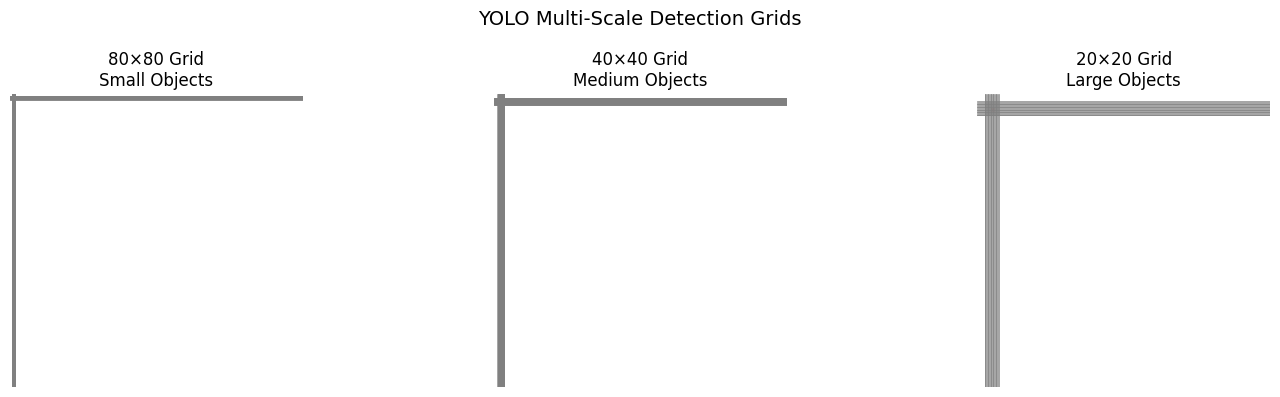

📊 Total predictions: 80×80 + 40×40 + 20×20 = 8,400 grid cells
   Each cell predicts 85 numbers (80 classes + 4 box + 1 objectness)
   Total outputs: 714,000 values per image!


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (grid_size, title) in enumerate(zip([80, 40, 20], ['Small Objects', 'Medium Objects', 'Large Objects'])):
    ax = axes[idx]
    
    # Create grid
    img = np.ones((grid_size, grid_size, 3))
    ax.imshow(img)
    
    # Draw grid lines
    for i in range(grid_size):
        ax.axhline(y=i/grid_size, color='gray', linewidth=0.5)
        ax.axvline(x=i/grid_size, color='gray', linewidth=0.5)
    
    # Highlight one cell
    cell_x, cell_y = grid_size//2, grid_size//2
    rect = patches.Rectangle((cell_x/grid_size, cell_y/grid_size), 
                            1/grid_size, 1/grid_size,
                            linewidth=2, edgecolor='red', facecolor='red', alpha=0.3)
    ax.add_patch(rect)
    
    ax.set_title(f'{grid_size}×{grid_size} Grid\n{title}')
    ax.axis('off')

plt.suptitle('YOLO Multi-Scale Detection Grids', fontsize=14)
plt.tight_layout()
plt.show()

print(f"📊 Total predictions: 80×80 + 40×40 + 20×20 = {80*80 + 40*40 + 20*20:,} grid cells")
print("   Each cell predicts 85 numbers (80 classes + 4 box + 1 objectness)")
print(f"   Total outputs: {(80*80 + 40*40 + 20*20) * 85:,} values per image!")

## 🎯 Did You Notice?

The grid has THREE sizes because:
- Small grid (80×80): Finds small objects (distant cars)
- Medium grid (40×40): Finds medium objects
- Large grid (20×20): Finds large objects (close people)

**This multi-scale approach is why YOLO finds objects of ALL sizes!**

## 4.3 The YOLO Family

In [32]:
yolo_family = {
    'Nano (n)': {'params': '3.2M', 'speed': '⚡⚡⚡⚡⚡', 'map': 37.3, 'use': 'Mobile, real-time'},
    'Small (s)': {'params': '11.2M', 'speed': '⚡⚡⚡⚡', 'map': 44.9, 'use': 'General purpose'},
    'Medium (m)': {'params': '25.9M', 'speed': '⚡⚡⚡', 'map': 50.2, 'use': 'Balanced'},
    'Large (l)': {'params': '43.7M', 'speed': '⚡⚡', 'map': 52.9, 'use': 'High accuracy'},
    'XLarge (x)': {'params': '68.2M', 'speed': '⚡', 'map': 53.9, 'use': 'Maximum accuracy'}
}

print(f"\n{'Model':<12} {'Params':<10} {'Speed':<12} {'mAP':<8} {'Best For'}")
print("-"*60)
for model, info in yolo_family.items():
    print(f"{model:<12} {info['params']:<10} {info['speed']:<12} {info['map']:<8.1f} {info['use']}")

print("\n🎯 PRO TIP: Start with Nano for experimentation, scale up for production")


Model        Params     Speed        mAP      Best For
------------------------------------------------------------
Nano (n)     3.2M       ⚡⚡⚡⚡⚡        37.3     Mobile, real-time
Small (s)    11.2M      ⚡⚡⚡⚡         44.9     General purpose
Medium (m)   25.9M      ⚡⚡⚡          50.2     Balanced
Large (l)    43.7M      ⚡⚡           52.9     High accuracy
XLarge (x)   68.2M      ⚡            53.9     Maximum accuracy

🎯 PRO TIP: Start with Nano for experimentation, scale up for production


## 📊 REAL-WORLD PERFORMANCE BENCHMARKS

Here's what you can expect on different hardware:

In [33]:
performance_benchmarks = {
    "Edge Device (RPi 4)": {
        "YOLOv8n": "15-20 FPS",
        "YOLOv5s": "10-12 FPS",
        "Faster R-CNN": "1-2 FPS (impractical)"
    },
    "Mobile Phone (TFLite)": {
        "YOLOv8n": "25-30 FPS",
        "YOLOv5s": "15-20 FPS"
    },
    "Laptop (No GPU)": {
        "YOLOv8n": "8-12 FPS",
        "YOLOv5s": "5-8 FPS"
    },
    "Desktop (GTX 1060)": {
        "YOLOv8n": "60-80 FPS",
        "YOLOv8s": "40-50 FPS",
        "YOLOv8m": "25-35 FPS"
    },
    "Desktop (RTX 3090)": {
        "YOLOv8n": "150-200 FPS",
        "YOLOv8s": "100-120 FPS",
        "YOLOv8m": "70-90 FPS"
    }
}

print("\n" + "="*60)
print("📊 REAL-WORLD PERFORMANCE BENCHMARKS")
print("="*60)

for device, models in performance_benchmarks.items():
    print(f"\n{device}:")
    for model, fps in models.items():
        print(f"   • {model}: {fps}")

print("\n💡 PRO TIP: Always test on your target hardware before finalizing model choice!")


📊 REAL-WORLD PERFORMANCE BENCHMARKS

Edge Device (RPi 4):
   • YOLOv8n: 15-20 FPS
   • YOLOv5s: 10-12 FPS
   • Faster R-CNN: 1-2 FPS (impractical)

Mobile Phone (TFLite):
   • YOLOv8n: 25-30 FPS
   • YOLOv5s: 15-20 FPS

Laptop (No GPU):
   • YOLOv8n: 8-12 FPS
   • YOLOv5s: 5-8 FPS

Desktop (GTX 1060):
   • YOLOv8n: 60-80 FPS
   • YOLOv8s: 40-50 FPS
   • YOLOv8m: 25-35 FPS

Desktop (RTX 3090):
   • YOLOv8n: 150-200 FPS
   • YOLOv8s: 100-120 FPS
   • YOLOv8m: 70-90 FPS

💡 PRO TIP: Always test on your target hardware before finalizing model choice!


## 🎮 Now You Know YOLO's Theory. Let's Become the Pilot!

Theory + Practice = Success. But every model needs tuning for your specific use case.

**Think of these parameters as your flight controls:**
- **Confidence**: How sure the model must be (like a pilot's certainty)
- **IoU**: How much overlap to allow (like minimum safe distance)
- **Max Det**: How many objects to report (like air traffic capacity)

**Let's fly...**

# 🎮 PART 5: The YOLO Tuning Playground

In [ ]:
@widgets.interact(
    confidence=widgets.FloatSlider(
        value=0.25,
        min=0.1,
        max=0.9,
        step=0.05,
        description='Confidence:'
    ),
    iou=widgets.FloatSlider(
        value=0.5,
        min=0.1,
        max=0.9,
        step=0.05,
        description='IoU:'
    ),
    max_det=widgets.IntSlider(
        value=100,
        min=10,
        max=300,
        step=10,
        description='Max Det:'
    )
)
def tune_yolo(confidence, iou, max_det):
    # Run YOLO with custom parameters
    results = yolo_model('assets/zidane.jpg', conf=confidence, iou=iou, max_det=max_det)[0]
    
    # Show result
    plt.figure(figsize=(12, 8))
    plt.imshow(results.plot())
    plt.axis('off')
    plt.title(
        f'Conf: {confidence:.2f}, IoU: {iou:.2f}, Max: {max_det} | '
        f'{len(results.boxes)} detections'
    )
    plt.show()
    
    # Explanation
    print("PARAMETER EFFECTS:")
    print(
        f"• Confidence {confidence:.2f}: " +
        ("Many detections (more false positives)" if confidence < 0.3 
         else "Fewer, higher-quality detections")
    )
    print(
        f"• IoU {iou:.2f}: " +
        ("Less overlap allowed (stronger NMS)" if iou > 0.6 
         else "More overlapping boxes kept")
    )
    print(f"• Max Det {max_det}: Maximum boxes returned")

interactive(children=(FloatSlider(value=0.25, description='Confidence:', max=0.9, min=0.1, step=0.05), FloatSl…

## 🎮 What Did Your Sliders Do?

- **Low confidence (0.1):** Saw everything (even ghosts!)
- **High confidence (0.7):** Missed some real objects
- **Sweet spot (0.25-0.5):** Balanced detection

**This is EXACTLY how you'll tune real systems.**

Now, what happens when things go wrong? Let's learn to debug...

# 🛠️ PART 9: Professional Debugging Toolkit

## 🚨 Common Mistakes & Solutions

In [35]:
mistakes = {
    "Wrong image size": {
        "symptom": "No detections or weird boxes",
        "solution": "YOLO expects 640×640, resize properly!"
    },
    "Class indices off by one": {
        "symptom": "All detections have wrong labels",
        "solution": "YOLO uses 0-indexed classes!"
    },
    "Confidence too high": {
        "symptom": "Missing objects",
        "solution": "Start with 0.25, adjust based on use case"
    },
    "IoU threshold too low": {
        "symptom": "Multiple boxes around same object",
        "solution": "Increase IoU to 0.5-0.7"
    }
}

for i, (problem, info) in enumerate(mistakes.items(), 1):
    print(f"\n{i}. 🚨 {problem}")
    print(f"   📍 Symptom: {info['symptom']}")
    print(f"   💡 Solution: {info['solution']}")


1. 🚨 Wrong image size
   📍 Symptom: No detections or weird boxes
   💡 Solution: YOLO expects 640×640, resize properly!

2. 🚨 Class indices off by one
   📍 Symptom: All detections have wrong labels
   💡 Solution: YOLO uses 0-indexed classes!

3. 🚨 Confidence too high
   📍 Symptom: Missing objects
   💡 Solution: Start with 0.25, adjust based on use case

4. 🚨 IoU threshold too low
   📍 Symptom: Multiple boxes around same object
   💡 Solution: Increase IoU to 0.5-0.7


## 🔬 DEBUGGING VISUALIZATIONS - Understand What Your Model Sees


image 1/1 /home/silva/SILVA.AI/Projects/SAIR/4_PyTorch/2_Vision_and_CNN/street.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 12.1ms
Speed: 14.7ms preprocess, 12.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


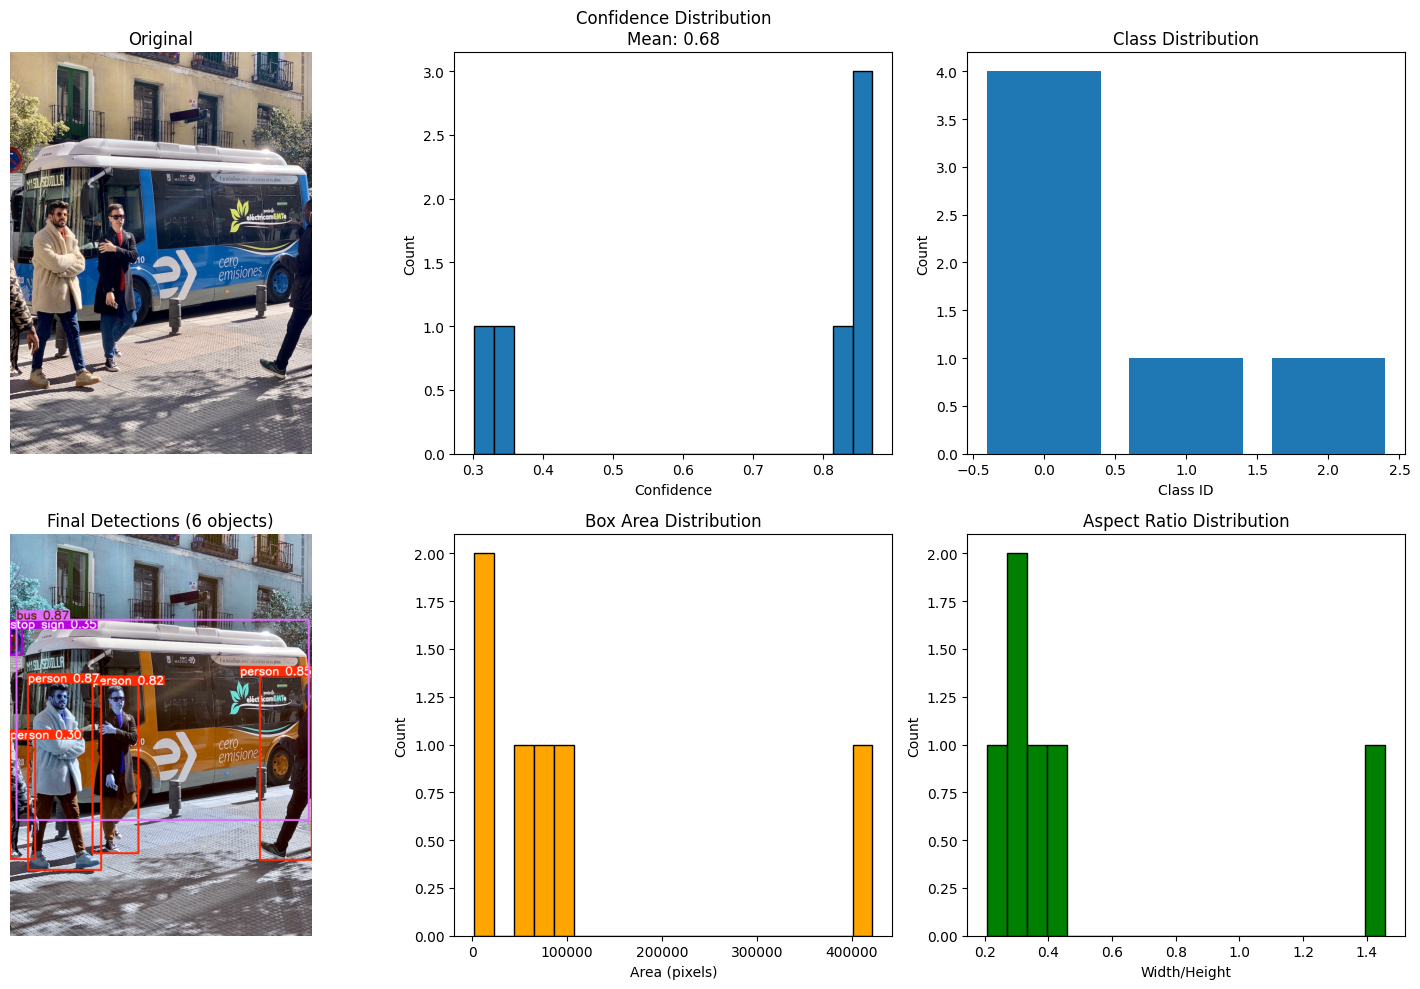


📊 Detection Summary:
   Total objects: 6
   Average confidence: 0.677
   Unique classes: 3
   Average box area: 111512 pixels


In [36]:
def debug_yolo_predictions(image_path, model, confidence=0.25):
    """Show what YOLO 'sees' at each stage"""
    results = model(image_path, conf=confidence)[0]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0,0].imshow(img)
    axes[0,0].set_title("Original")
    axes[0,0].axis('off')
    
    # Confidence distribution
    if len(results.boxes) > 0:
        confs = results.boxes.conf.cpu().numpy()
        axes[0,1].hist(confs, bins=20, edgecolor='black')
        axes[0,1].set_title(f"Confidence Distribution\nMean: {np.mean(confs):.2f}")
        axes[0,1].set_xlabel("Confidence")
        axes[0,1].set_ylabel("Count")
    else:
        axes[0,1].text(0.5, 0.5, "No detections", ha='center', va='center')
        axes[0,1].set_title("Confidence Distribution")
    
    # Class distribution
    if len(results.boxes) > 0:
        classes = results.boxes.cls.cpu().numpy()
        unique, counts = np.unique(classes, return_counts=True)
        axes[0,2].bar(range(len(unique)), counts)
        axes[0,2].set_title("Class Distribution")
        axes[0,2].set_xlabel("Class ID")
        axes[0,2].set_ylabel("Count")
    else:
        axes[0,2].text(0.5, 0.5, "No detections", ha='center', va='center')
        axes[0,2].set_title("Class Distribution")
    
    # Final detections
    axes[1,0].imshow(results.plot())
    axes[1,0].set_title(f"Final Detections ({len(results.boxes)} objects)")
    axes[1,0].axis('off')
    
    # Box size distribution
    if len(results.boxes) > 0:
        boxes = results.boxes.xyxy.cpu().numpy()
        areas = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])
        axes[1,1].hist(areas, bins=20, edgecolor='black', color='orange')
        axes[1,1].set_title("Box Area Distribution")
        axes[1,1].set_xlabel("Area (pixels)")
        axes[1,1].set_ylabel("Count")
    else:
        axes[1,1].text(0.5, 0.5, "No detections", ha='center', va='center')
        axes[1,1].set_title("Box Area Distribution")
    
    # Aspect ratio distribution
    if len(results.boxes) > 0:
        boxes = results.boxes.xyxy.cpu().numpy()
        aspect_ratios = (boxes[:,2] - boxes[:,0]) / (boxes[:,3] - boxes[:,1] + 1e-6)
        axes[1,2].hist(aspect_ratios, bins=20, edgecolor='black', color='green')
        axes[1,2].set_title("Aspect Ratio Distribution")
        axes[1,2].set_xlabel("Width/Height")
        axes[1,2].set_ylabel("Count")
    else:
        axes[1,2].text(0.5, 0.5, "No detections", ha='center', va='center')
        axes[1,2].set_title("Aspect Ratio Distribution")
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n📊 Detection Summary:")
    print(f"   Total objects: {len(results.boxes)}")
    if len(results.boxes) > 0:
        print(f"   Average confidence: {np.mean(confs):.3f}")
        print(f"   Unique classes: {len(unique)}")
        print(f"   Average box area: {np.mean(areas):.0f} pixels")

# Run debug visualization
debug_yolo_predictions('street.jpg', yolo_model)

## 📊 Parameter Cheat Sheet

In [43]:
cheat_sheet = """
┌──────────────┬─────────────────────────────────────┬──────────────────┐
│ Parameter    │ What it does                        │ Recommended      │
├──────────────┼─────────────────────────────────────┼──────────────────┤
│ epochs       │ Number of passes through data       │ 50-300           │
│ batch        │ Images per update                   │ Max that fits    │
│ imgsz        │ Input image size                    │ 640 (default)    │
│ lr0          │ Initial learning rate               │ 0.01 for fine-tune│
│ augment      │ Data augmentation                   │ ALWAYS TRUE      │
│ patience     │ Early stopping patience             │ 50-100           │
│ freeze       │ Number of layers to freeze          │ 10 for transfer  │
│ conf         │ Confidence threshold                │ 0.25 (general)   │
│ iou          │ NMS IoU threshold                   │ 0.5 (standard)   │
│ max_det      │ Maximum detections per image        │ 300 (default)    │
└──────────────┴─────────────────────────────────────┴──────────────────┘
"""

print(cheat_sheet)


┌──────────────┬─────────────────────────────────────┬──────────────────┐
│ Parameter    │ What it does                        │ Recommended      │
├──────────────┼─────────────────────────────────────┼──────────────────┤
│ epochs       │ Number of passes through data       │ 50-300           │
│ batch        │ Images per update                   │ Max that fits    │
│ imgsz        │ Input image size                    │ 640 (default)    │
│ lr0          │ Initial learning rate               │ 0.01 for fine-tune│
│ augment      │ Data augmentation                   │ ALWAYS TRUE      │
│ patience     │ Early stopping patience             │ 50-100           │
│ freeze       │ Number of layers to freeze          │ 10 for transfer  │
│ conf         │ Confidence threshold                │ 0.25 (general)   │
│ iou          │ NMS IoU threshold                   │ 0.5 (standard)   │
│ max_det      │ Maximum detections per image        │ 300 (default)    │
└──────────────┴────────────────────

## 🚀 Ready for the Final Challenge?

You've learned:
1. ✅ How detection builds on CNNs
2. ✅ The three pillars (BBox, IoU, NMS)
3. ✅ YOLO architecture and tuning
4. ✅ Debugging techniques

**Now let's train YOUR first detector!**

# 🎯 PART 10: Mini-Challenge - Your First Detector

## 🚀 Train YOLO on a Simple Dataset (Quick Version)

**Goal:** Train a detector on 1 class in under 30 minutes

In [37]:
print("="*60)
print("MINI-CHALLENGE: TRAIN YOUR FIRST DETECTOR")
print("="*60)

# Download practice dataset
!wget -q -O coco128.zip https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
!unzip -q -o coco128.zip -d datasets/
print("✅ Downloaded COCO128 practice dataset")

MINI-CHALLENGE: TRAIN YOUR FIRST DETECTOR
✅ Downloaded COCO128 practice dataset


In [38]:
import yaml

# Create dataset YAML
dataset_path = os.path.abspath('datasets/coco128')
data_yaml = {
    'path': dataset_path,
    'train': 'images/train2017',
    'val': 'images/train2017',
    'nc': 80,
    'names': ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
              'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat',
              'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
              'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
              'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
              'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
              'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
              'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
              'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
              'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
}

with open('coco128.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

print("✅ Created coco128.yaml")

✅ Created coco128.yaml


```markdown
## 🚀 THE MAGIC COMMAND

**Important:** There are TWO ways to train YOLO:

1. **From scratch** (using `.yaml`): Slower, needs lots of data
2. **From pre-trained** (using `.pt`): Faster, better results (RECOMMENDED!)

```
┌─────────────────────────────────────────────────────────┐
│  model = YOLO('yolov8n.yaml')  → Train from SCRATCH    │
│  model = YOLO('yolov8n.pt')    → Fine-tune PRE-TRAINED │
└─────────────────────────────────────────────────────────┘
```

**For 99% of projects, use pre-trained weights!** They already know how to see - they just need to learn YOUR specific objects.
```

## 🤔 Why `.pt` instead of `.yaml`?

| Aspect | `.yaml` (from scratch) | `.pt` (pre-trained) |
|--------|----------------------|---------------------|
| **Starting point** | Random weights | Already knows edges, shapes, objects |
| **Data needed** | 1000s of images | 50-100 images often enough |
| **Training time** | Days | Hours |
| **Accuracy** | Low initially | High from the start |
| **Use case** | Research, novel architectures | **EVERYTHING ELSE** |

**Think of it like this:**
- `.yaml` = Teaching a baby to see from birth
- `.pt` = Taking a teenager who already sees, and teaching them YOUR specific objects

## 🔍 After Training: Find Your Model

YOLO saves multiple versions:
```
runs/detect/train/
├── weights/
│   ├── last.pt  # Model from final epoch
│   └── best.pt  # Best model during training (USE THIS!)
├── results.png  # Training charts
└── confusion_matrix.png  # Performance breakdown

In [39]:
# UNCOMMENT TO TRAIN
model = YOLO('yolov8n.pt')
results = model.train(
     data='coco128.yaml',
     epochs=10,  # Increase to 50-100 for real projects
     imgsz=640,
     batch=8,
     device=0 if torch.cuda.is_available() else 'cpu',
     augment=True)
print("✅ Training complete! Check runs/detect/train/")

Ultralytics 8.4.14 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 3715MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

## 🔬 UNDER THE HOOD: What Ultralytics YOLO Does for You

When you run `model.train()`, Ultralytics abstracts away **A LOT** of complexity. Here's what's really happening:

### 1. 🏗️ Model Architecture Setup

**What you write:**
```python
model = YOLO('yolov8n.pt')
```

**What actually happens:**
```python
# Pseudocode of what Ultralytics does internally
1. Loads the YAML configuration (network architecture)
2. Downloads pre-trained weights from cloud storage
3. Builds the complete model:
   - Backbone: CSPDarknet (feature extractor)
   - Neck: PANet (feature fusion across scales)
   - Heads: 3 detection heads (80×80, 40×40, 20×20 grids)
4. Sets up loss functions:
   - Classification loss (BCEWithLogitsLoss)
   - Box regression loss (CIoU Loss)
   - Distribution Focal Loss (DFL)
5. Initializes optimizer (SGD with momentum by default)
```

### 2. 📊 Data Pipeline (The Hidden Engine)

```python
# What Ultralytics sets up automatically:
- Automatic train/val split
- Mosaic augmentation (combines 4 images)
- MixUp augmentation
- Random affine transforms (rotate, scale, shear)
- HSV augmentation (color jitter)
- Letterbox resizing (maintains aspect ratio)
- Automatic caching for faster loading
```

### 3. 🔄 The Training Loop (What Actually Runs)

```
for epoch in range(epochs):
    for batch in dataloader:
        # Forward pass
        predictions = model(images)
        
        # Calculate losses (THIS IS COMPLEX!)
        loss_cls = classification_loss(predictions, targets)  # What object?
        loss_box = ciou_loss(predictions, targets)            # How accurate?
        loss_dfl = distribution_focal_loss(predictions)       # Better localization
        
        # Total loss (weighted combination)
        loss = loss_cls * 0.5 + loss_box * 7.5 + loss_dfl * 1.5
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        
        # Optimizer step
        optimizer.step()
        
        # Update learning rate (cosine decay scheduler)
        scheduler.step()
        
        # EMA (Exponential Moving Average) for better stability
        ema.update(model)
```

### 4. 🎯 The Anchor-Free Magic

Traditional YOLO used anchors (pre-defined box shapes). YOLOv8 is **anchor-free**:

```python
# What YOLOv8 does internally:
for each grid cell (80×80, 40×40, 20×20):
    # Instead of predicting offsets from anchors
    # It directly predicts:
    - class probabilities (80 values)
    - box coordinates (4 values: center x, center y, width, height)
    - objectness score (1 value)
    
    # The magic: It learns WHAT shapes to look for
    # No more hand-picking anchor boxes!
```

### 5. 📈 What Those Loss Numbers Mean

```
Epoch 1: Loss = 3.85
├── Classification loss: 1.2 (Model unsure what objects are)
├── Box loss: 2.3 (Boxes are way off)
└── DFL loss: 0.35 (Learning to localize)

Epoch 10: Loss = 1.42
├── Classification loss: 0.4 (Learning your objects)
├── Box loss: 0.8 (Boxes getting closer)
└── DFL loss: 0.22 (Better localization)

Epoch 50: Loss = 0.76
├── Classification loss: 0.15 (Confident in classes)
├── Box loss: 0.45 (Accurate boxes)
└── DFL loss: 0.16 (Precise boundaries)
```

### 6. 🎨 What Augmentation Really Does

```python
# Ultralytics applies these transforms automatically:
def mosaic_augmentation(images, targets):
    """Combine 4 images into one"""
    # Takes 4 training images
    # Stitches them together
    # Adjusts bounding boxes accordingly
    # Model sees more variety = better generalization

def mixup_augmentation(images, targets):
    """Blend two images together"""
    # alpha = random(0.3, 0.7)
    # mixed_image = alpha * image1 + (1-alpha) * image2
    # mixed_targets = combine both
    # Model learns to handle occlusion
```

### 7. 💾 What Gets Saved (And Why)

```
runs/detect/train/
├── weights/
│   ├── last.pt  
│   │   └── Contains: model.state_dict(), optimizer.state_dict(), 
│   │                epoch number, training configuration
│   │
│   └── best.pt
│       └── Same as above, but from epoch with best validation mAP
│
├── results.png
│   └── Plots: loss curves, mAP curves, learning rate schedule
│
├── confusion_matrix.png
│   └── Shows: which classes get confused with which
│
├── labels.jpg
│   └── Visualizes: your training annotations
│
└── hyp.yaml
    └── Complete hyperparameter configuration used
```

### 8. 🔧 What You CAN Control vs What's Abstracted

| You Control | Ultralytics Handles |
|------------|-------------------|
| `epochs` | Learning rate scheduling |
| `batch` | Gradient accumulation |
| `imgsz` | Automatic resizing |
| `device` | Multi-GPU distribution |
| `augment` | Which augments and parameters |
| `patience` | Early stopping logic |
| `optimizer` | Weight decay, momentum schedules |

### 9. 🧠 The Real Magic: What's NOT in the Code

```python
# Things Ultralytics does silently:
1. Automatic mixed precision (faster training on GPUs)
2. Gradient checkpointing (memory optimization)
3. Warmup epochs (gradually increase LR)
4. EMA model for inference (more stable)
5. Automatic batch size adjustment
6. Multi-scale training (randomly vary input size)
7. SyncBN for multi-GPU
8. Automatic model compilation (if available)
```

### 10. 📊 The Validation Dance

Every epoch, this happens silently:

```python
model.eval()
with torch.no_grad():
    for images, targets in val_dataloader:
        predictions = model(images)
        
        # Calculate metrics:
        - mAP@0.5 (IoU threshold 0.5)
        - mAP@0.5:0.95 (average across thresholds)
        - Precision
        - Recall
        
        # If mAP improves:
        save_checkpoint('best.pt')
```

## 🎯 Why This Matters

Understanding what's under the hood helps you:
1. **Debug effectively** when training fails
2. **Choose better hyperparameters** (not just guessing)
3. **Know what to expect** during training
4. **Appreciate** how much work Ultralytics saves you
5. **Move beyond** just using the library to truly mastering it

**Ultralytics isn't magic - it's just really good engineering that hides complexity so you can focus on YOUR data and problem!**
```


image 1/1 /home/silva/SILVA.AI/Projects/SAIR/4_PyTorch/2_Vision_and_CNN/street.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 18.8ms
Speed: 36.4ms preprocess, 18.8ms inference, 27.8ms postprocess per image at shape (1, 3, 640, 480)


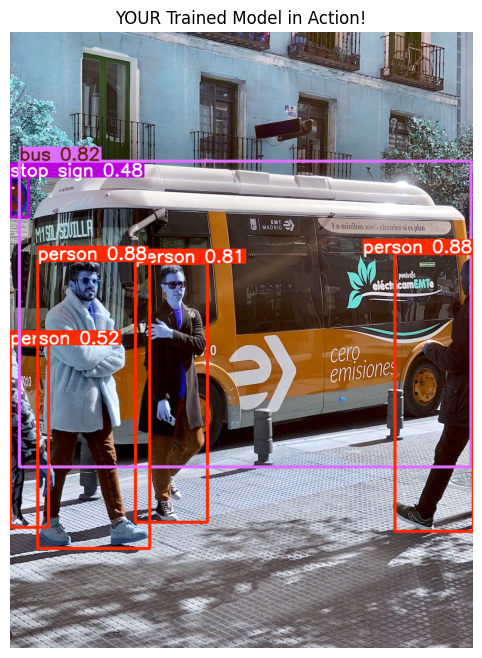

In [41]:
best_model = YOLO('/home/silva/SILVA.AI/Projects/SAIR/runs/detect/train9/weights/best.pt')  # Load best weights
results = best_model('street.jpg')

plt.figure(figsize=(12, 8))
plt.imshow(results[0].plot())
plt.axis('off')
plt.title("YOUR Trained Model in Action!")
plt.show()

# ✅ MASTERY CHECKLIST

## Before Moving to Lecture 5B (Segmentation & Pose)

In [ ]:
print("""
╔═══════════════════════════════════════════════════════════════════╗
║                      MASTERY CHECKLIST                            ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║ Before moving to Lecture 5B, ensure you can:                     ║
║                                                                   ║
║ □ Explain how detection builds on CNNs (Part 2)                  ║
║ □ Convert between 4 bounding box formats (Part 3.1)              ║
║ □ Calculate IoU by hand (Part 3.2)                               ║
║ □ Explain how NMS works (Part 3.3)                               ║
║ □ Use YOLO for real-time detection (Part 4)                      ║
║ □ Tune confidence, IoU, max_det (Part 5)                         ║
║ □ Debug common issues (Part 9)                                   ║
║ □ Train a detector on simple data (Part 10)                      ║
║                                                                   ║
║ 🎉 If you checked all: YOU'RE READY FOR LECTURE 5B!              ║
║                                                                   ║
╚═══════════════════════════════════════════════════════════════════╝
""")

# 📝 POST-LECTURE ASSESSMENT

In [ ]:
def post_lecture_quiz():
    """Final assessment to check mastery"""
    questions = [
        {
            "q": "What does NMS (Non-Maximum Suppression) do?",
            "options": [
                "Increases confidence of detections",
                "Removes duplicate detections of same object",
                "Adds more bounding boxes",
                "Converts box formats"
            ],
            "correct": 1,
            "explanation": "NMS removes overlapping boxes with lower confidence scores"
        },
        {
            "q": "Which YOLO model is best for mobile deployment?",
            "options": ["YOLOv8x", "YOLOv8l", "YOLOv8m", "YOLOv8n"],
            "correct": 3,
            "explanation": "YOLOv8n (nano) is smallest and fastest, ideal for mobile"
        },
        {
            "q": "What IoU value indicates a good detection?",
            "options": ["<0.3", "0.3-0.5", "0.5-0.7", ">0.7"],
            "correct": 2,
            "explanation": "IoU > 0.5 is considered good, >0.7 is excellent"
        }
    ]
    
    score = 0
    print("\n" + "="*60)
    print("📝 POST-LECTURE MASTERY ASSESSMENT")
    print("="*60)
    
    for i, q in enumerate(questions, 1):
        print(f"\n{i}. {q['q']}")
        for j, opt in enumerate(q['options']):
            print(f"   {j}. {opt}")
        try:
            ans = int(input("Your answer: "))
            if ans == q['correct']:
                print("✅ Correct!")
                score += 1
            else:
                print(f"❌ Incorrect. {q['explanation']}")
        except:
            print("❌ Please enter a number")
    
    percentage = (score / len(questions)) * 100
    print(f"\n{'='*60}")
    print(f"FINAL SCORE: {score}/{len(questions)} ({percentage:.0f}%)")
    
    if percentage >= 80:
        print("🌟 EXCELLENT! You're ready for Lecture 5B!")
    elif percentage >= 60:
        print("👍 Good foundation. Review missed concepts before 5B.")
    else:
        print("📚 Review this notebook before moving to 5B.")

# Uncomment to take final assessment
# post_lecture_quiz()

# 🎯 WHAT'S NEXT?

## Lecture 5B: Segmentation, Pose & Gesture Control

You've mastered **detection** (what + where).  
Next, you'll learn:

- 🎨 **Segmentation**: From boxes to pixel-perfect masks
- 🦾 **Pose Estimation**: Track 17 body keypoints in real-time
- ✨ **Gesture Control**: Control computers with your hands!
- 📸 **Data Collection**: Turn your phone into a dataset generator
- 🎓 **Train Custom Models**: Build YOUR gesture controller

**See you in 5B!** 🚀

---

<div style="text-align: center; padding: 20px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; border-radius: 10px;">
    <h1>🌟 From Pixels to Understanding 🌟</h1>
    <p style="font-size: 18px; font-style: italic;">"You started with CNNs. Now you can detect anything."</p>
    <p><strong>SAIR Community - Sudanese Artificial Intelligence Research</strong></p>
    <p>🇸🇩 Building Sudan's AI Future, One Model at a Time</p>
</div>